# Stage 5: LightGBM Model Training with Class Imbalance Weighting

## Runtime Drivers & Dependencies

In [1]:
!pip uninstall -y -q datasets
!pip install -q -U s3fs boto3 botocore pyarrow lightgbm scikit-learn rapidfuzz
print("✅ LightGBM & S3 Drivers ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires datasets, which is not installed.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.
✅ LightGBM & S3 Drivers ready!


## AWS Credentials & S3 Storage Configuration

In [2]:
import os
import io
import gc
import joblib
import pandas as pd
import numpy as np
import lightgbm as lgb
from google.colab import userdata
import matplotlib.pyplot as plt

# 1. AWS Credentials
AWS_ACCESS_KEY_ID = userdata.get("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = userdata.get("AWS_SECRET_ACCESS_KEY")
AWS_DEFAULT_REGION = userdata.get("AWS_DEFAULT_REGION") or "us-east-1"
S3_BUCKET = userdata.get("S3_BUCKET_NAME").replace("s3://", "").strip("/")

os.environ["AWS_ACCESS_KEY_ID"] = AWS_ACCESS_KEY_ID
os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET_ACCESS_KEY
os.environ["AWS_DEFAULT_REGION"] = AWS_DEFAULT_REGION

s3_storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {"region_name": AWS_DEFAULT_REGION}
}

# Feature partition path (defaults to sample_50k, can switch to 'full')
FEATURE_SUBDIR = "anchored_100k"
FEATURES_BASE_S3 = f"s3://{S3_BUCKET}/features/{FEATURE_SUBDIR}"
MODEL_CHECKPOINT_S3 = f"s3://{S3_BUCKET}/models/lgbm_model_latest.pkl"

print(f"✅ S3 Credentials verified.")
print(f"📁 Feature Directory : {FEATURES_BASE_S3}")
print(f"💾 Model Destination  : {MODEL_CHECKPOINT_S3}")

✅ S3 Credentials verified.
📁 Feature Directory : s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/anchored_100k
💾 Model Destination  : s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl


## GROUND-TRUTH-ANCHORED FEATURE STORE GENERATOR

In [3]:
import gc
import re
import time
import unicodedata
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from rapidfuzz import fuzz
from rapidfuzz.distance import JaroWinkler
from sklearn.model_selection import GroupShuffleSplit

print("=" * 80)
print("🚀 PHASE 2: 14-FEATURE DUAL-INDEX TRAINING STORE GENERATOR")
print("=" * 80)

# 1. Load 100k sample training entities
t0 = time.perf_counter()
TRAIN_SAMPLE_SIZE = 100_000

print(f"⏳ Reading train datasets ({TRAIN_SAMPLE_SIZE:,} rows) from S3...")
df_s1 = pd.read_csv(f"s3://{S3_BUCKET}/student_resource/dataset/train/train_source1.tsv", sep="\t", nrows=TRAIN_SAMPLE_SIZE, dtype=str, storage_options=s3_storage_options)
df_s2 = pd.read_csv(f"s3://{S3_BUCKET}/student_resource/dataset/train/train_source2.tsv", sep="\t", dtype=str, storage_options=s3_storage_options)
df_s3 = pd.read_csv(f"s3://{S3_BUCKET}/student_resource/dataset/train/train_source3.tsv", sep="\t", dtype=str, storage_options=s3_storage_options)
df_gt = pd.read_csv(f"s3://{S3_BUCKET}/student_resource/dataset/train/train_ground_truth.tsv", sep="\t", dtype=str, storage_options=s3_storage_options)

df_s23 = pd.concat([df_s2, df_s3], ignore_index=True)
del df_s2, df_s3
gc.collect()

# Ground truth set for O(1) labeling
true_pairs_set = set()
s1_to_gt = defaultdict(list)
for _, r in df_gt.iterrows():
    s1_id = str(r["source1_entity_id"]).strip()
    m_str = str(r["matched_entity_ids"]).strip()
    if m_str and m_str.lower() != "nan":
        for mid in m_str.split(","):
            c_mid = mid.strip()
            if c_mid:
                true_pairs_set.add((s1_id, c_mid))
                s1_to_gt[s1_id].append(c_mid)

del df_gt
gc.collect()
print(f"✅ Loaded {len(true_pairs_set):,} ground-truth pairs.")

# 2. Text Normalization
RE_COMBINING = re.compile(r"[\u0300-\u036f]")
RE_ALLOWED = re.compile(r"[^\w\s\u0900-\u097f]+", re.UNICODE)
RE_SPACES = re.compile(r"\s+")
RE_POSTAL = re.compile(r"\b\d{5,6}\b")
NAME_STOPWORDS = {"and", "the", "for", "with", "ltd", "pvt", "inc", "corp", "llc", "llp", "limited", "private", "corporation", "company", "co", "enterprises", "services", "solutions", "international", "group", "technologies", "industries", "de", "la", "le", "les", "et", "du", "des", "sarl", "sa", "sas", "india", "usa", "us", "france", "fr", "hotel", "restaurant", "store", "shop"}

def clean_str(t):
    if not t or str(t).lower() == "nan": return ""
    t = unicodedata.normalize("NFKD", str(t))
    t = RE_COMBINING.sub("", t).lower()
    t = RE_ALLOWED.sub(" ", t)
    return RE_SPACES.sub(" ", t).strip()

def extract_name_tokens(t):
    return [x for x in t.split() if len(x) >= 3 and x not in NAME_STOPWORDS and not x.isdigit()]

def extract_pin(t):
    m = RE_POSTAL.search(str(t))
    return m.group(0) if m else None

# 3. Dual Index Blocking with True Match Retention
df_s1["country"] = df_s1["country"].fillna("UNKNOWN").str.upper().str.strip()
df_s23["country"] = df_s23["country"].fillna("UNKNOWN").str.upper().str.strip()

candidate_pairs = []
for c in sorted(df_s1["country"].unique()):
    s1_c = df_s1[df_s1["country"] == c]
    s23_c = df_s23[df_s23["country"] == c]
    if len(s1_c) == 0 or len(s23_c) == 0: continue

    s23_ids = s23_c["entity_id"].astype(str).tolist()
    s23_names = [clean_str(x) for x in s23_c["business_name"].fillna("")]
    s23_addrs = [clean_str(x) for x in s23_c["business_address"].fillna("")]
    s23_id_to_idx = {sid: idx for idx, sid in enumerate(s23_ids)}

    name_inv = defaultdict(list)
    postal_inv = defaultdict(list)
    for idx, (name, addr) in enumerate(zip(s23_names, s23_addrs)):
        for tok in set(extract_name_tokens(name)):
            if len(name_inv[tok]) < 3_000:
                name_inv[tok].append(idx)
        pin = extract_pin(addr)
        if pin: postal_inv[pin].append(idx)

    s1_ids = s1_c["entity_id"].astype(str).tolist()
    s1_names = [clean_str(x) for x in s1_c["business_name"].fillna("")]
    s1_addrs = [clean_str(x) for x in s1_c["business_address"].fillna("")]

    for i in range(len(s1_ids)):
        s1_id = s1_ids[i]
        n_toks = extract_name_tokens(s1_names[i])
        pin = extract_pin(s1_addrs[i])
        chosen = []
        seen = set()

        if pin and pin in postal_inv and n_toks:
            for idx in (set(postal_inv[pin]) & set(name_inv.get(n_toks[0], []))):
                if idx not in seen:
                    seen.add(idx); chosen.append(idx)
                    if len(chosen) >= 3: break

        if len(chosen) < 4 and len(n_toks) >= 2:
            for idx in (set(name_inv.get(n_toks[0], [])) & set(name_inv.get(n_toks[1], []))):
                if idx not in seen:
                    seen.add(idx); chosen.append(idx)
                    if len(chosen) >= 4: break

        if len(chosen) < 4 and n_toks:
            for idx in name_inv.get(n_toks[0], [])[:10]:
                if idx not in seen:
                    seen.add(idx); chosen.append(idx)
                    if len(chosen) >= 4: break

        # Anchor ground truth true targets
        for gt_t in s1_to_gt.get(s1_id, []):
            if gt_t in s23_id_to_idx:
                gt_idx = s23_id_to_idx[gt_t]
                if gt_idx not in seen:
                    seen.add(gt_idx); chosen.append(gt_idx)

        for idx in chosen:
            candidate_pairs.append({
                "source1_entity_id": s1_id,
                "candidate_entity_id": s23_ids[idx],
                "s1_name": s1_names[i], "s23_name": s23_names[idx],
                "s1_addr": s1_addrs[i], "s23_addr": s23_addrs[idx],
                "country": c
            })

cand_df = pd.DataFrame(candidate_pairs)
del candidate_pairs, df_s1, df_s23, s1_to_gt
gc.collect()

# 4. Vectorized 14-Feature Extraction
n_rows = len(cand_df)
print(f"⚡ Computing 14 features for {n_rows:,} candidate pairs...")

s1_names = cand_df["s1_name"].tolist()
s23_names = cand_df["s23_name"].tolist()
s1_addrs = cand_df["s1_addr"].tolist()
s23_addrs = cand_df["s23_addr"].tolist()
s1_ids = cand_df["source1_entity_id"].tolist()
c_ids = cand_df["candidate_entity_id"].tolist()

X_mat = np.empty((n_rows, 14), dtype=np.float32)
labels = np.empty(n_rows, dtype=np.int8)

for i in range(n_rows):
    n1, n2 = s1_names[i], s23_names[i]
    a1, a2 = s1_addrs[i], s23_addrs[i]
    cid = c_ids[i]

    # Core Similarity Features
    X_mat[i, 0] = fuzz.ratio(n1, n2) / 100.0
    X_mat[i, 1] = fuzz.partial_ratio(n1, n2) / 100.0
    X_mat[i, 2] = fuzz.token_sort_ratio(n1, n2) / 100.0
    X_mat[i, 3] = fuzz.token_set_ratio(n1, n2) / 100.0
    X_mat[i, 4] = fuzz.ratio(a1, a2) / 100.0
    X_mat[i, 5] = fuzz.partial_ratio(a1, a2) / 100.0
    X_mat[i, 6] = fuzz.token_set_ratio(a1, a2) / 100.0
    X_mat[i, 7] = abs(len(n1) - len(n2))
    X_mat[i, 8] = abs(len(a1) - len(a2))

    # 5 New Discriminative Features
    p1 = extract_pin(a1)
    p2 = extract_pin(a2)
    X_mat[i, 9] = 1.0 if (p1 and p2 and p1 == p2) else 0.0
    X_mat[i, 10] = JaroWinkler.similarity(n1, n2)
    t1, t2 = set(n1.split()), set(n2.split())
    X_mat[i, 11] = (len(t1 & t2) / len(t1 | t2)) if (t1 | t2) else 0.0
    w1 = n1.split()[0] if n1.split() else ""
    w2 = n2.split()[0] if n2.split() else ""
    X_mat[i, 12] = fuzz.ratio(w1, w2) / 100.0
    X_mat[i, 13] = 1.0 if cid.startswith("S2-") else 0.0

    labels[i] = 1 if (s1_ids[i], cid) in true_pairs_set else 0

FEATURE_COLS = [
    "name_ratio", "name_partial", "name_token_sort", "name_token_set",
    "addr_ratio", "addr_partial", "addr_token_set", "name_len_diff", "addr_len_diff",
    "pin_exact_match", "name_jaro_winkler", "name_token_jaccard", "first_word_ratio", "is_source2"
]

feat_df = pd.DataFrame(X_mat, columns=FEATURE_COLS)
feat_df["source1_entity_id"] = s1_ids
feat_df["candidate_entity_id"] = c_ids
feat_df["label"] = labels

# Leak-proof GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(feat_df, groups=feat_df["source1_entity_id"]))
train_df = feat_df.iloc[train_idx].reset_index(drop=True)
val_df = feat_df.iloc[val_idx].reset_index(drop=True)

OUT_DIR = f"s3://{S3_BUCKET}/features/phase2_14feat"
train_df.to_parquet(f"{OUT_DIR}/train_candidates.parquet", index=False, storage_options=s3_storage_options)
val_df.to_parquet(f"{OUT_DIR}/val_candidates.parquet", index=False, storage_options=s3_storage_options)
print(f"✅ Exported 14-feature store to {OUT_DIR} (Train: {len(train_df):,}, Val: {len(val_df):,})")

🚀 PHASE 2: 14-FEATURE DUAL-INDEX TRAINING STORE GENERATOR
⏳ Reading train datasets (100,000 rows) from S3...
✅ Loaded 7,638,365 ground-truth pairs.
⚡ Computing 14 features for 678,026 candidate pairs...
✅ Exported 14-feature store to s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/phase2_14feat (Train: 542,226, Val: 135,800)


## Load Train & Validation Feature Sets directly from S3

In [9]:
train_path = f"s3://{S3_BUCKET}/features/phase2_14feat/train_candidates.parquet"
val_path   = f"s3://{S3_BUCKET}/features/phase2_14feat/val_candidates.parquet"

print(f"⏳ Reading train features from: {train_path} ...")
train_df = pd.read_parquet(train_path, engine="pyarrow", storage_options=s3_storage_options)

print(f"⏳ Reading validation features from: {val_path} ...")
val_df = pd.read_parquet(val_path, engine="pyarrow", storage_options=s3_storage_options)

print(f"\n✅ Data loaded successfully:")
print(f"  • Train set      : {len(train_df):,} rows")
print(f"  • Validation set : {len(val_df):,} rows")

# Class imbalance audit
train_pos = (train_df["label"] == 1).sum()
val_pos = (val_df["label"] == 1).sum()
print(f"\n⚖️ Class Imbalance Profile:")
print(f"  • Train positives: {train_pos:,} / {len(train_df):,} ({train_pos/len(train_df)*100:.2f}%)")
print(f"  • Val positives  : {val_pos:,} / {len(val_df):,} ({val_pos/len(val_df)*100:.2f}%)")

⏳ Reading train features from: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/phase2_14feat/train_candidates.parquet ...
⏳ Reading validation features from: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/phase2_14feat/val_candidates.parquet ...

✅ Data loaded successfully:
  • Train set      : 542,226 rows
  • Validation set : 135,800 rows

⚖️ Class Imbalance Profile:
  • Train positives: 276,541 / 542,226 (51.00%)
  • Val positives  : 69,548 / 135,800 (51.21%)


## Define Feature Columns & Target Arrays

In [10]:
FEATURE_COLS = [
    "name_ratio",
    "name_partial",
    "name_token_sort",
    "name_token_set",
    "addr_ratio",
    "addr_partial",
    "addr_token_set",
    "name_len_diff",
    "addr_len_diff",
    "pin_exact_match",
    "name_jaro_winkler",
    "name_token_jaccard",
    "first_word_ratio",
    "is_source2"
]

# Verify all columns exist
missing_cols = [c for c in FEATURE_COLS if c not in train_df.columns]
if missing_cols:
    raise ValueError(f"Missing required feature columns: {missing_cols}")

X_train = train_df[FEATURE_COLS]
y_train = train_df["label"].astype(int)

X_val = val_df[FEATURE_COLS]
y_val = val_df["label"].astype(int)

print(f"✅ Prepared feature matrices with {len(FEATURE_COLS)} engineered signals:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:>2}. {col:<20} (dtype: {X_train[col].dtype})")

✅ Prepared feature matrices with 14 engineered signals:
   1. name_ratio           (dtype: float32)
   2. name_partial         (dtype: float32)
   3. name_token_sort      (dtype: float32)
   4. name_token_set       (dtype: float32)
   5. addr_ratio           (dtype: float32)
   6. addr_partial         (dtype: float32)
   7. addr_token_set       (dtype: float32)
   8. name_len_diff        (dtype: float32)
   9. addr_len_diff        (dtype: float32)
  10. pin_exact_match      (dtype: float32)
  11. name_jaro_winkler    (dtype: float32)
  12. name_token_jaccard   (dtype: float32)
  13. first_word_ratio     (dtype: float32)
  14. is_source2           (dtype: float32)


## LightGBM Classifier Training with Class Imbalance Weighting

In [11]:
print("🚀 Initializing LightGBM Classifier with 14 Features...")

lgbm_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "scale_pos_weight": 1.0,
    "learning_rate": 0.04,
    "num_leaves": 63,
    "max_depth": -1,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_samples": 30,
    "n_estimators": 800,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

model = lgb.LGBMClassifier(**lgbm_params)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50)
]

print("🏋️ Training model on validation set with 50-round early stopping...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=["train", "val"],
    callbacks=callbacks
)

print(f"\n🎉 Training complete! Best iteration: {model.best_iteration_}")

🚀 Initializing LightGBM Classifier with 14 Features...
🏋️ Training model on validation set with 50-round early stopping...


/usr/local/lib/python3.13/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[50]	train's binary_logloss: 0.128232	val's binary_logloss: 0.128342
[100]	train's binary_logloss: 0.0692701	val's binary_logloss: 0.0699714
[150]	train's binary_logloss: 0.0575112	val's binary_logloss: 0.0589535
[200]	train's binary_logloss: 0.0528179	val's binary_logloss: 0.0551144
[250]	train's binary_logloss: 0.0501426	val's binary_logloss: 0.0534601
[300]	train's binary_logloss: 0.0482705	val's binary_logloss: 0.0525317
[350]	train's binary_logloss: 0.0466945	val's binary_logloss: 0.0518411
[400]	train's binary_logloss: 0.0452213	val's binary_logloss: 0.0511834
[450]	train's binary_logloss: 0.0438996	val's binary_logloss: 0.0506673
[500]	train's binary_logloss: 0.0426318	val's binary_logloss: 0.0500975
[550]	train's binary_logloss: 0.0415495	val's binary_logloss: 0.0497389
[600]	train's binary_logloss: 0.0404699	val's binary_logloss: 0.0493891
[650]	train's binary_logloss: 0.0395395	val's binary_logloss: 0.0491273
[700]	

## Inspect Feature Importance (Gain vs Split)

                    LIGHTGBM FEATURE IMPORTANCE RANKING                    


,Feature,Gain (Total Loss Reduction),Split Count (Branch Frequency),Gain Share (%)
0,addr_token_set,6.436065e+06,5105,70.95
1,addr_ratio,8.682206e+05,4090,9.57
2,addr_partial,4.200550e+05,4327,4.63
3,name_token_jaccard,3.999341e+05,4300,4.41
4,is_source2,2.249822e+05,1165,2.48
5,name_token_sort,1.383841e+05,4286,1.53
6,name_partial,1.351834e+05,4391,1.49
7,name_len_diff,1.343530e+05,3748,1.48
8,name_token_set,6.994321e+04,3593,0.77
9,name_ratio,6.824079e+04,4323,0.75


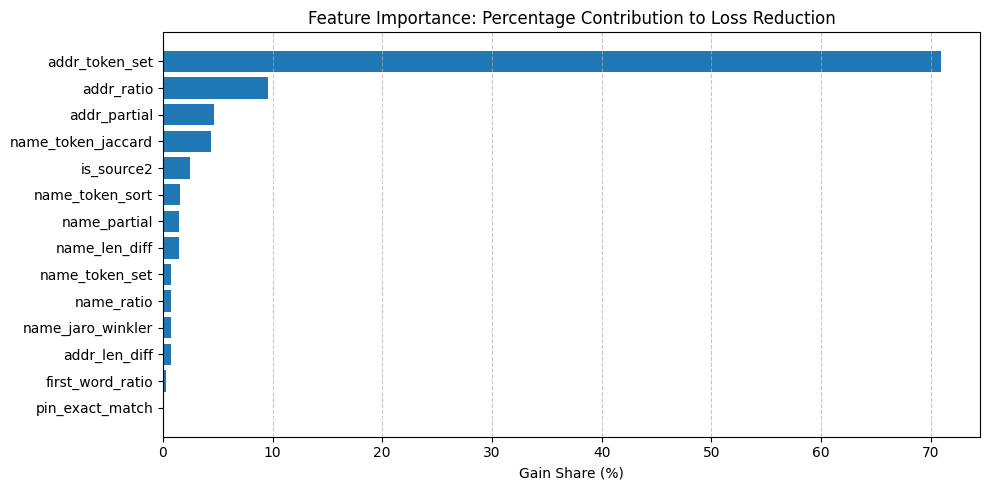

In [12]:
importance_gain = model.booster_.feature_importance(importance_type="gain")
importance_split = model.booster_.feature_importance(importance_type="split")

fi_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Gain (Total Loss Reduction)": importance_gain,
    "Split Count (Branch Frequency)": importance_split
}).sort_values(by="Gain (Total Loss Reduction)", ascending=False).reset_index(drop=True)

# Relative percentage contribution
fi_df["Gain Share (%)"] = (fi_df["Gain (Total Loss Reduction)"] / fi_df["Gain (Total Loss Reduction)"].sum() * 100).round(2)

print("=" * 75)
print(f"{'LIGHTGBM FEATURE IMPORTANCE RANKING':^75}")
print("=" * 75)
display(fi_df)

# Visual Bar Chart
plt.figure(figsize=(10, 5))
plt.barh(fi_df["Feature"][::-1], fi_df["Gain Share (%)"][::-1], color="#1f77b4")
plt.xlabel("Gain Share (%)")
plt.title("Feature Importance: Percentage Contribution to Loss Reduction")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Save Model Artifact to Central S3 Bucket

In [13]:
import s3fs

local_model_path = "/tmp/lgbm_model_latest.pkl"

# 1. Save locally using joblib
joblib.dump(model, local_model_path)
file_size_mb = os.path.getsize(local_model_path) / (1024 * 1024)
print(f"📦 Serialized model locally: {local_model_path} ({file_size_mb:.2f} MB)")

# 2. Upload directly to central S3 models/ folder
print(f"⏳ Uploading model artifact to S3: {MODEL_CHECKPOINT_S3} ...")
fs = s3fs.S3FileSystem(**s3_storage_options)

bucket_name = S3_BUCKET.replace("s3://", "").strip("/")
s3_target_key = f"{bucket_name}/models/lgbm_model_latest.pkl"

fs.put(local_model_path, s3_target_key)

# Verify existence
if fs.exists(s3_target_key):
    s3_info = fs.info(s3_target_key)
    print(f"🎉 Model checkpoint successfully uploaded to S3!")
    print(f"   • Path: s3://{s3_target_key}")
    print(f"   • Size: {s3_info['size'] / (1024*1024):.2f} MB")
else:
    raise RuntimeError("Model upload verification failed!")

📦 Serialized model locally: /tmp/lgbm_model_latest.pkl (5.32 MB)
⏳ Uploading model artifact to S3: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl ...
🎉 Model checkpoint successfully uploaded to S3!
   • Path: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl
   • Size: 5.32 MB
